# Thực hành 5: Bài toán thỏa mãn ràng buộc

In [77]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



## 1. Bài toán sinh tổ hợp

Cho tập hợp A có N phần tử đôi một khác nhau. Mỗi phần tử là một ký tự từ A → Z. Hãy liệt kê các tập hợp của tập
hợp có N phần tử lấy từ K phần tử.

In [78]:
%%writefile tohop.inp
3 2
F
A
B

Overwriting tohop.inp


### Đọc dữ liệu

In [79]:
from tohop import *

n, k, comb = readFile(filepath="tohop.inp")
print(f'n = {n}\nk = {k}\ncomb = {comb}')


Data file read successfully!
n = 3
k = 2
comb = ['F', 'A', 'B']


### Cài đăt backtracking

In [80]:
backtracking(n=n, k=k, result=[], build=[], combination=comb, start=0, debug=True)

[]
['F']
['F', 'A']
Các tổ hợp: [['F', 'A']]

pop: A
['F']
['F', 'B']
Các tổ hợp: [['F', 'A'], ['F', 'B']]

pop: B
['F']
pop: F
[]
['A']
['A', 'B']
Các tổ hợp: [['F', 'A'], ['F', 'B'], ['A', 'B']]

pop: B
['A']
pop: A
[]
['B']
pop: B
[]


### Sinh tổ hợp

In [81]:
result = combine(n=n, k=k, combination = comb, debug=False)
print_result(result)

3
FA
FB
AB


### Kiểm tra thuật toán

In [82]:
import math

combination = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N']
tests = [
    (5, 3),
    (6, 2),
    (7, 3),
    (8, 4),
    (10, 3),
    (10, 5),
    (14, 5),
]

for n, k in tests:
    agg = combination[:n]
    expected = math.comb(n, k)
    result = combine(n=n, k=k, combination=agg)

    ok = (len(result) == expected)
    print(f'n={n:2} k={k:2}  backtracking={len(result):5}  nCk={expected:5}  {"PASS" if ok else "FAIL"}')

n= 5 k= 3  backtracking=   10  nCk=   10  PASS
n= 6 k= 2  backtracking=   15  nCk=   15  PASS
n= 7 k= 3  backtracking=   35  nCk=   35  PASS
n= 8 k= 4  backtracking=   70  nCk=   70  PASS
n=10 k= 3  backtracking=  120  nCk=  120  PASS
n=10 k= 5  backtracking=  252  nCk=  252  PASS
n=14 k= 5  backtracking= 2002  nCk= 2002  PASS


## 2. Xếp hậu (đặt N quân hậu)

Xét bàn cờ tổng quát kích thước NxN. Một quân hậu trên bàn cờ có thể ăn được các quân khác nằm tại các ô cùng
hàng, cùng cột hoặc cùng đường chéo. Hãy liệt kê tất cả các cách xếp N quân hậu trên bàn cờ sao cho không có quân
hậu nào ăn nhau. (3<=N<=100).(Làm hai cách: đệ quy quay lui và tham lam từng phần)

In [83]:
%%writefile xephau.inp
5

Overwriting xephau.inp


### Đọc dữ liệu

In [84]:
from xephau import *

n = readFile("xephau.inp")
print(f'n = {n}')

Đọc dữ liệu thành công!
n = 5


### Cách 1: Backtracking

```
backtracking(n, col)
    nếu col == N return SUCCESS //đặt đủ hậu
    else
        Với mỗi dòng trong cột col:
            Thử thêm hậu vào bàn cờ
            backtracking(n, col + 1) // sang cột tiếp theo
            Lấy hậu ra sau khi thử
        
xephau(n)
    Ban đồ bàn cờ rỗng
    backtracking(n, col = 0)
```



#### Kiểm tra xung đột

In [85]:
"""
                                            + + Q +       
pos = [1,3,0,2] tương đương với bàn cờ :    Q + + +
                                            + + + Q
                                            + Q + +

check_valid(0, 1, pos = [1,3,0,2]) : kiểm tra ô [0,1] có xung đột với các hậu khác không
trả về True (hợp lệ) và False (có xung đột)
"""
valid = check_valid(0, 1, pos = [1,3,0,2])  
print(valid)

False


### Backtracking

In [86]:
result = xephau_bactracking(n)
print(f'Tất cả các nghiệm: ({len(result)} nghiệm)')
print(result)

Tất cả các nghiệm: (10 nghiệm)
[[0, 2, 4, 1, 3], [0, 3, 1, 4, 2], [1, 3, 0, 2, 4], [1, 4, 2, 0, 3], [2, 0, 3, 1, 4], [2, 4, 1, 3, 0], [3, 0, 2, 4, 1], [3, 1, 4, 2, 0], [4, 1, 3, 0, 2], [4, 2, 0, 3, 1]]


### Kết quả

In [87]:
if len(result) > 0: 
    pos_v = result[0]
    print(1)
    print_board(board(n,pos_v))
    pass
else: print(0)


1
1 0 0 0 0 
0 0 0 1 0 
0 1 0 0 0 
0 0 0 0 1 
0 0 1 0 0 



#### Vẽ cây backtracking với n = {3, 4}

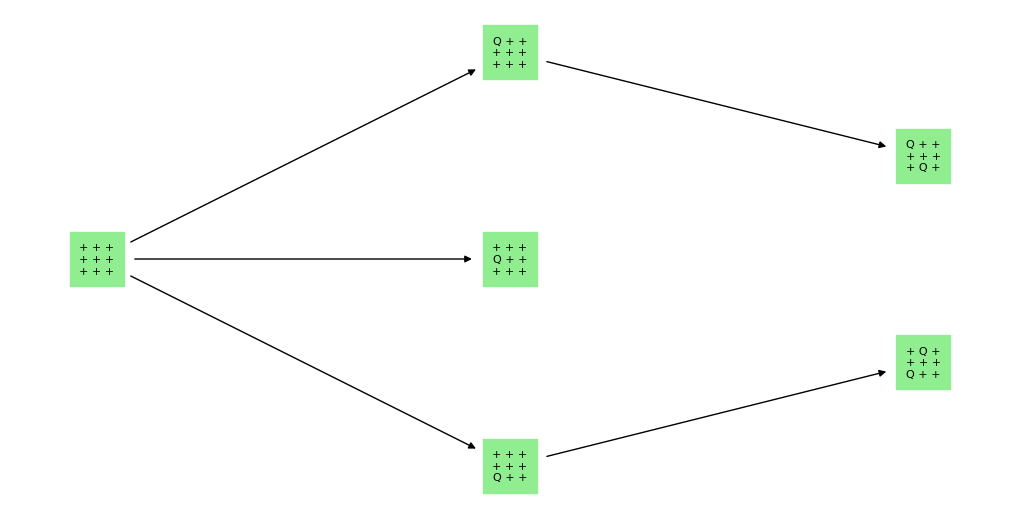

Vô nghiệm


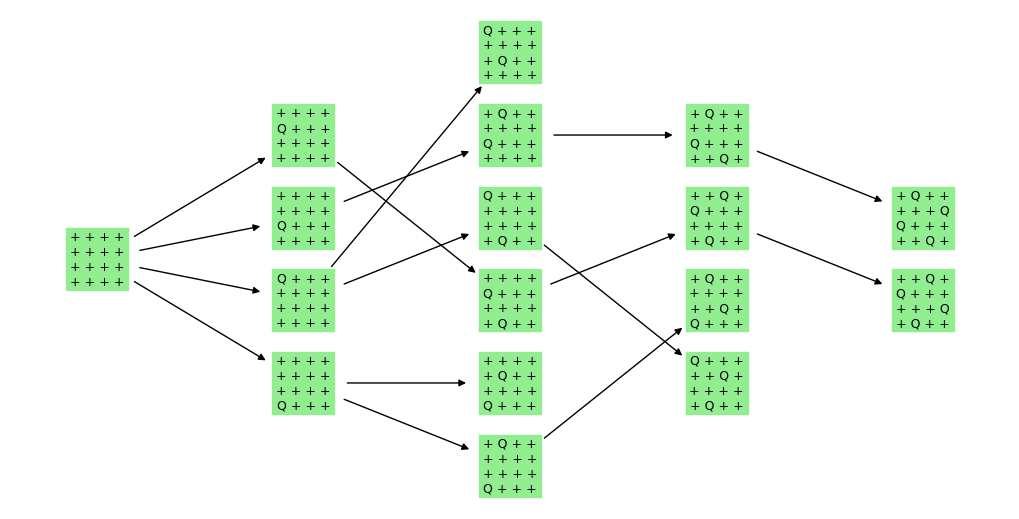

[[1, 3, 0, 2], [2, 0, 3, 1]]

In [88]:
xephau_bactracking(n = 3, draw_tree = True, queens=True)
xephau_bactracking(n = 4, draw_tree = True, queens=True)

### Cách 2: Tham lam từng phần (Min-Conflicts)

```
xephau(n):
    Khởi tạo ngẫu nhiên 1 hậu mỗi cột
    Lặp tối đa K bước: (K có thể là n^2 hoặc 10*n,100*n)
        h = số cặp xung đột
        nếu h == 0: return SUCCESS
        chọn ngẫu nhiên cột curr đang bị xung đột
        chọn row trong cột curr sao cho số xung đột là nhỏ nhất
        di chuyển hậu ở curr tới row đó
    return FAILURE
```

#### Tính tổng số cặp đang xung đột (heuristic chính)


In [89]:
a_pos = [0,0,0,0,0,0,0,0,0] # trên cùng cột nến số cặp xung đột là nCr(9,2) = 36 cặp tấn công nhau 
count_conflicting_pairs(a_pos)

36

#### Tính số xung đột tại một ô với các cột khác

In [90]:
"""
X . . + . . + . .       
Q + . + . + . . .   
Q . + + + . . . .    
Q + + O + + + + +    
Q . + + + . . . .    
Q + . + . + . . .    
X . . + . . + . .    
Q . . + . . . + .   
"""
count_conflicts_of_cell(3,3,a_pos) # Ô (3,3) xung đột với hậu ô (0,0) và (6,0) không tính hàng đang xét

2

#### Cài đặt tham lam

In [91]:
pos = xephau_thamlam(n, step=True)

Giả sử ban đầu ta đặt các hậu ở hàng 0
pos = [0, 0, 0, 0, 0]
  h = 10
[[1 1 1 1 1]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]

  h = 6
[[1 1 0 1 1]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 1 0 0]]

  h = 4
[[1 0 0 1 1]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 1 0 0]]

  h = 2
[[1 0 0 1 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 1]
 [0 1 1 0 0]]

  h = 2
[[1 0 0 1 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 1]
 [0 1 1 0 0]]

  h = 1
[[0 0 0 1 0]
 [1 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 1]
 [0 1 1 0 0]]

  h = 1
[[0 0 0 1 0]
 [1 1 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 1 0 0]]

  h = 1
[[0 0 0 1 0]
 [1 1 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 1 0 0]]

  h = 1
[[0 0 0 1 0]
 [1 1 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 1 0 0]]

  h = 1
[[0 0 0 1 0]
 [0 1 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 1]
 [1 0 1 0 0]]

  h = 1
[[0 0 0 1 0]
 [0 1 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 1]
 [1 0 1 0 0]]

  h = 1
[[0 0 0 1 0]
 [0 1 0 0 0]
 [0 0 0 0 0]
 [0 0 1 0 1]
 [1 0 0 0 0]]

  h = 1
[[0 0 0 1 0]
 [0 1 0 0 0]
 [0 

#### Kết quả

In [92]:
if pos is None:
    print(0)
else:
    print(1)
    print(board_to_string(board(n, pos)))

0


## 3. Mã đi tuần (đường đóng)

*Xem thêm: https://en.wikipedia.org/wiki/Knight%27s_tour*

Trong bàn cờ tổng quát kích thước NxN, con mã được đặt tại vị trí x0, y0. Hãy chỉ ra lộ trình con mã đi qua tất cả
các ô mà mỗi ô chỉ đi qua đúng một lần và trở lại vị trí ban đầu. (2<=N<=10).


In [215]:
%%writefile madituan.inp
6 1 6

Overwriting madituan.inp


### Đọc dữ liệu

In [216]:
from madituan import *
n, x0, y0 = readFile("madituan.inp")
print(f'n = {n}, x0 = {x0}, y0 = {y0}')

Đọc dữ liệu thành công!
n = 6, x0 = 1, y0 = 6


### Cách 1: Backtracking + tham lam (tối ưu hơn backtracking thuần túy)
```
n = kích thước bàn cờ
(x0,y0) tọa độ ô bắt đầu
board là bàn cờ rộng nxn

greedyBactracking(x, y)
    nếu đã đi tất cả các ô và quay về ô ban đầu
        return SUCCESS
    chọn lần lượt các ô tiếp theo (x_n, y_n) có bậc nhỏ nhất:
        board[x_n][y_n] = board[x][y] + 1
        greedyBacktracking(x_n, y_n)
        đặt lại board[x_n][y_n] = 0 nếu đã thử xong
    return FAILURE

madituan(n, x0, y0)
    khởi tạo bàn cờ board với các giá trị 0
    board[x0][y0] = 1 // đặt mã
    greedyBacktracking(x0, y0)
```

#### Tính bậc của một ô trên bàn cờ

In [217]:
import numpy as np
bac(n = n, x = 1, y = 1, board = np.zeros((n,n), dtype=int) )

4

#### Cài đặt

In [235]:
result = madituan_bactracking(n = n, x0 = x0, y0 = y0, limit = (False, 100000000))
print(result)

[[[12, 3, 24, 21, 10, 1], [25, 20, 11, 2, 31, 22], [4, 13, 32, 23, 36, 9], [19, 26, 17, 8, 33, 30], [14, 5, 28, 35, 16, 7], [27, 18, 15, 6, 29, 34]]]


#### Kết quả

In [236]:
def in_ketqua(result):
    if result is None or len(result) == 0:
        print(0)
        return
    
    print(1)
    kq = result[0]
    for row in range(len(kq)):
        for col in range(len(kq)):
            print(f'{kq[row][col]:2}', end=" ")
        print()

in_ketqua(result)


1
12  3 24 21 10  1 
25 20 11  2 31 22 
 4 13 32 23 36  9 
19 26 17  8 33 30 
14  5 28 35 16  7 
27 18 15  6 29 34 


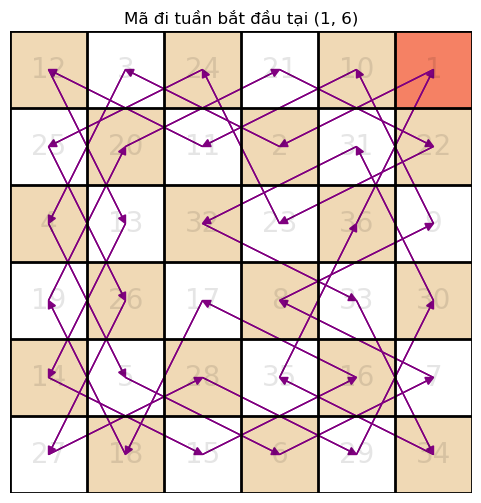

In [237]:
def vebanco(board, x, y):
    if board is None: return None
    else:
        n = len(board)
        plt.figure(figsize=(6,6))
        plt.title(f'Mã đi tuần bắt đầu tại {x,y}')
        plt.xlim(0,n)
        plt.ylim(0,n)
        for i in range(0, n+1): ## vẽ lưới
            plt.plot([0, n], [i, i], linewidth=2, color='black')
            plt.plot([i, i], [0, n], linewidth=2, color='black')
            pass
        for i in range(n): ## tô màu ô cho đẹp
            for j in range(n):
                if (i + j) % 2 == 0:
                    plt.fill([j, j+1, j+1, j],[i, i, i+1, i+1],color="#f0d9b5")
                    pass
                plt.fill([y-1, y, y, y-1],[x-1, x-1, x, x],color="#f58164")
                plt.text(j+0.5, i+0.5,str(board[i][j]),ha='center',va='center',fontsize=20,color='black',alpha = 0.1)
                pass
            pass
        pos = [None]*(n**2+1)
        for i in range(n):
            for j in range(n):
                pos[board[i][j]] = (i,j)

        for k in range(1, n*n): ## vẽ mũi tên đường đi
            x1, y1 = pos[k]
            x2, y2 = pos[k+1]
            plt.arrow(y1+0.5, x1+0.5,(y2 - y1), (x2 - x1),head_width=0.1,head_length=0.1,length_includes_head=True,color = 'purple')
            pass

        r1, c1 = pos[n**2]
        r2, c2 = pos[1]
        plt.arrow(c1+0.5, r1+0.5,(c2 - c1), (r2 - r1),head_width=0.1,head_length=0.1,length_includes_head=True,color = 'purple'        )

        plt.gca().invert_yaxis()
        plt.gca().set_aspect('equal')
        plt.axis("off")
        plt.show()
        pass
    
if result is None: print('Không có lời giải')
elif len(result) > 0:
    b = result[0]
    vebanco(b, x0, y0)
else: print('Không có lời giải')

### Cách 2: Tham lam + heuristic (sử dụng thêm restart+random tie để chắc chắn có lời giải)

```
madituan(n, x0, y0)
    while true:
        reset bàn cờ board
        đặt mã ở (x0,y0)
        x=x0, y=y0
        for i = 1 to n^2:
            nếu ở bước n^2-1:
                kiểm tra các ô tiếp theo, chọn ô có khả năng về lại (x0, y0), nếu không thì dừng lặp (vì không có lời giải)
            ngược lại:
                chọn ngẫu nhiên ô tiếp theo có bậc nhỏ nhất, nếu không có thì dừng lặp (vì đã kín lối đi)
            board[x0][y0] = i
        nếu bước cuối cùng có thể đi tới ô bắt đầu (x0,y0)
            return Solution
```         
*Chỉ có thể tìm được 1 kết quả*

#### Cài đặt tham lam + heuristic

In [238]:
result2 = []
board2 = madituan_heuristic(n = 8 , x0 = 1 , y0 = 8)
if board2 is None:
        print("Không tìm được lời giải")
else:
    result2.append([row[:] for row in board2])
print(result2)

[[[26, 13, 28, 63, 24, 15, 48, 1], [29, 58, 25, 14, 49, 64, 23, 16], [12, 27, 62, 57, 44, 51, 2, 47], [59, 30, 43, 50, 61, 46, 17, 22], [42, 11, 60, 45, 56, 21, 52, 3], [31, 8, 55, 40, 53, 34, 37, 18], [10, 41, 6, 33, 20, 39, 4, 35], [7, 32, 9, 54, 5, 36, 19, 38]]]


#### Kết quả

In [239]:
in_ketqua(result2)

1
26 13 28 63 24 15 48  1 
29 58 25 14 49 64 23 16 
12 27 62 57 44 51  2 47 
59 30 43 50 61 46 17 22 
42 11 60 45 56 21 52  3 
31  8 55 40 53 34 37 18 
10 41  6 33 20 39  4 35 
 7 32  9 54  5 36 19 38 


#### Biểu diễn hình ảnh

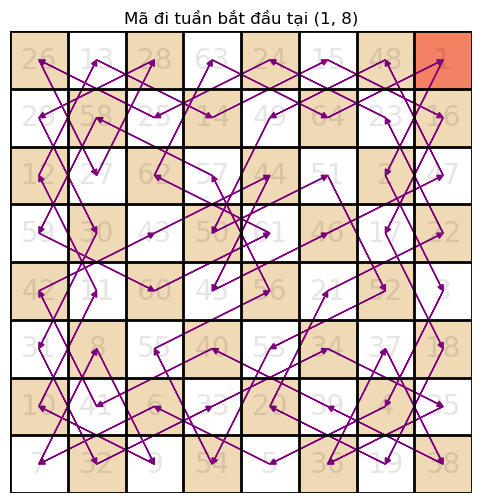

In [240]:
vebanco(board2, 1, 8)

## 4. Tô màu đồ thị

Xét bàn cờ tổng quát kích thước NxN. Một quân hậu trên bàn cờ có thể ăn được các quân khác nằm tại các ô cùng
hàng, cùng cột hoặc cùng đường chéo. Hãy liệt kê tất cả các cách xếp N quân hậu trên bàn cờ sao cho không có quân
hậu nào ăn nhau. (3<=N<=100).(Làm hai cách: đệ quy quay lui và tham lam từng phần)

In [241]:
%%writefile tomau.inp
9
1 2
1 4
1 5
2 3
3 4
3 7
4 5
4 6
5 6
5 9
6 8
6 9

Writing tomau.inp


# Kết thúc